#Imports

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import cv2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#Carregar os dados do Kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"stevansouza","key":"37f02b19af241c047574065077611d13"}'}

In [3]:
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d faizalkarim/flood-area-segmentation

import zipfile
with zipfile.ZipFile("flood-area-segmentation.zip", "r") as zip_ref:
    zip_ref.extractall("flood_data")

Dataset URL: https://www.kaggle.com/datasets/faizalkarim/flood-area-segmentation
License(s): CC0-1.0
flood-area-segmentation.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
base_dir = 'flood_data'
image_dir = os.path.join(base_dir, "Image")
mask_dir = os.path.join(base_dir, "Mask")
metadata_dir = os.path.join(base_dir, "metadata.csv")
metadata = pd.read_csv(metadata_dir)

#Definição de variaveis

In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 10
NUM_CLASSES = 2

image_paths = [os.path.join(image_dir, fname) for fname in metadata['Image']]
mask_paths = [os.path.join(mask_dir, fname) for fname in metadata['Mask']]

# Dataset Personalizado

In [7]:
class FloodDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        if image is None:
            image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = (mask > 127).astype(np.uint8)

        if self.transform:
            image = self.transform(image)

        mask = torch.from_numpy(mask).long()
        return image, mask

#Preparo dos dados

In [9]:
# Transformações
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Divide em treino/teste
train_imgs, test_imgs, train_masks, test_masks = train_test_split(image_paths, mask_paths, test_size=0.2, random_state=42)

train_dataset = FloodDataset(train_imgs, train_masks, transform=transform)
test_dataset = FloodDataset(test_imgs, test_masks, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


#Configuração do Modelo

In [10]:
# Modelo DeepLabV3+ com MobileNetV3
model = torchvision.models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=True)
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model = model.to(DEVICE)

# Função de perda e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Treinamento

In [11]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)['out']
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.5202
Epoch [2/10], Loss: 0.3849
Epoch [3/10], Loss: 0.3265
Epoch [4/10], Loss: 0.2985
Epoch [5/10], Loss: 0.2663
Epoch [6/10], Loss: 0.2591
Epoch [7/10], Loss: 0.2588
Epoch [8/10], Loss: 0.2352
Epoch [9/10], Loss: 0.2350
Epoch [10/10], Loss: 0.2202


# Métricas de acerto para os dados de teste

In [12]:
# Avaliação
model.eval()
total = 0
correct = 0
iou_scores = []

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs = model(images)['out']
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == masks).sum().item()
        total += masks.numel()

        intersection = ((preds == 1) & (masks == 1)).sum().item()
        union = ((preds == 1) | (masks == 1)).sum().item()
        if union > 0:
            iou_scores.append(intersection / union)

accuracy = correct / total
mean_iou = np.mean(iou_scores)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Mean IoU: {mean_iou:.4f}")


Test Accuracy: 0.8814
Mean IoU: 0.7394


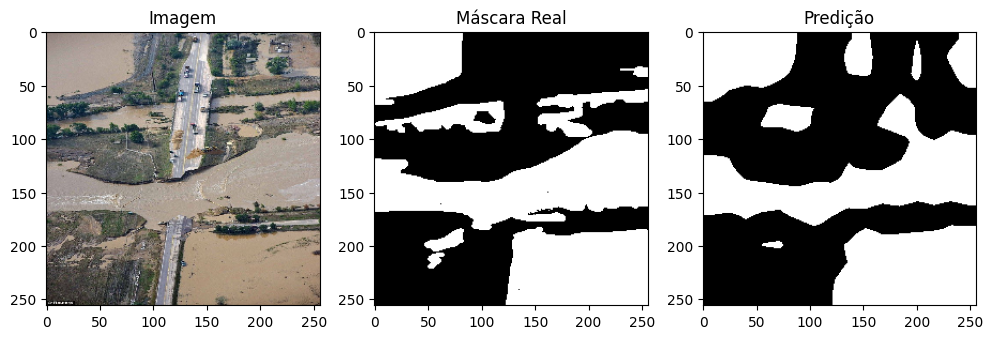

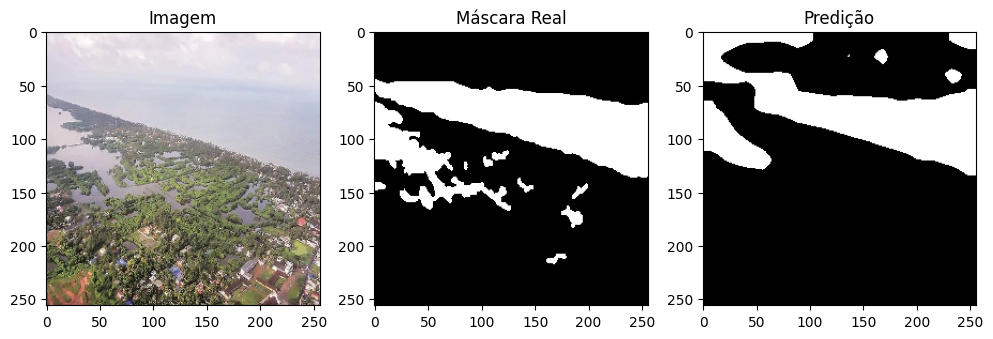

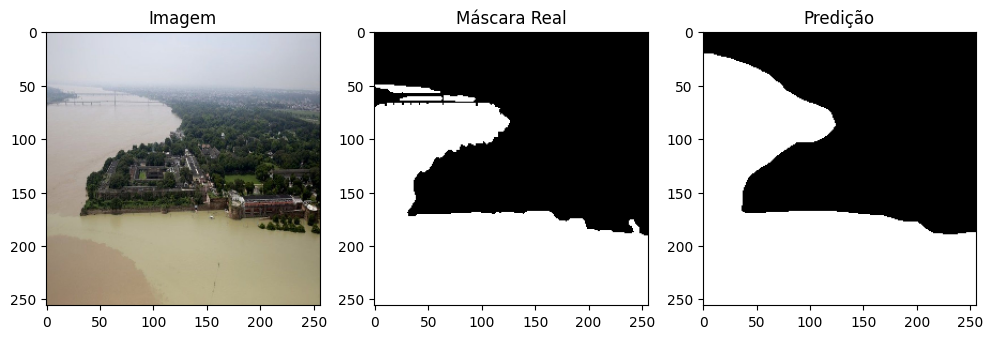

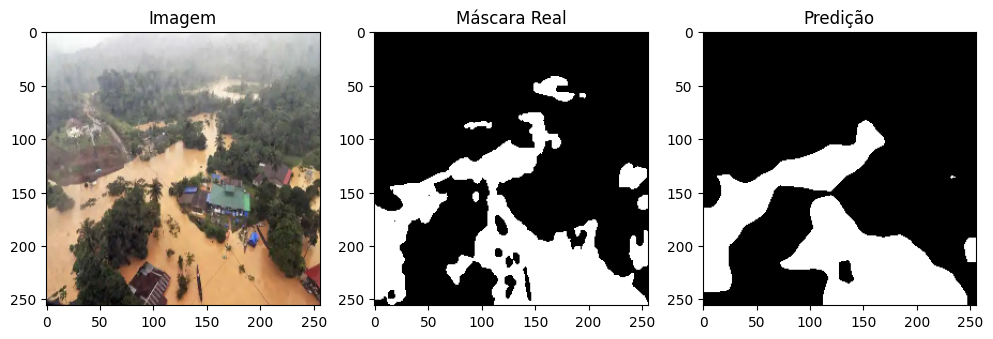

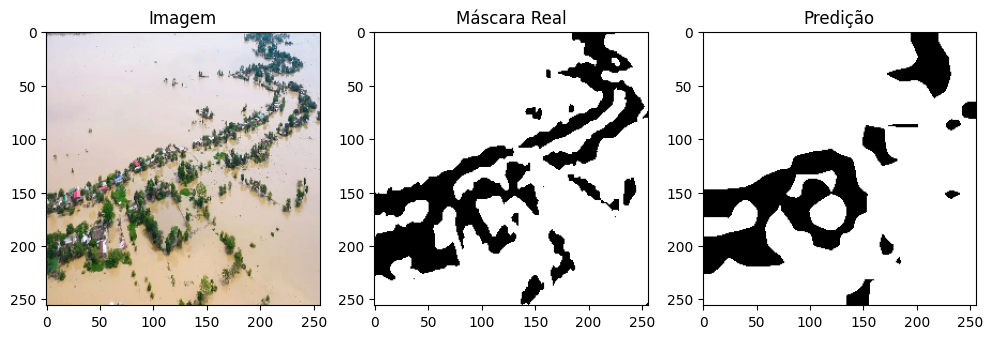

In [13]:
# Visualização
def visualize_predictions(model, dataset, num=5):
    model.eval()
    for i in range(num):
        image, true_mask = dataset[i]
        with torch.no_grad():
            pred = model(image.unsqueeze(0).to(DEVICE))['out']
            pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy()

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(image.permute(1, 2, 0).numpy() * 0.5 + 0.5)
        plt.title("Imagem")

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask.numpy(), cmap="gray")
        plt.title("Máscara Real")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Predição")
        plt.show()

visualize_predictions(model, test_dataset)